# ICU Time-Series Encoder — XGBoost + SHAP
> **Input** : `icu_hourly_features_24h.parquet` · `icu_static_features.parquet` · `icu_risk_scores.parquet`  
> **Output** : encoder feature matrix · predictions · SHAP values · visualisation report  
> **Targets** : mortality risk · sepsis alert · organ dysfunction · criticality tier  
> **Leakage policy** : split by `stay_id` before any scaling; score columns are targets-only

## Step 0 — Install Dependencies

In [ ]:
!pip install "Pillow==9.5.0" "scikit-image==0.21.0" "scikit-learn==1.3.2" --force-reinstall -q

# ── Install missing packages (run once per Colab session)
import subprocess, sys

PACKAGES = ['optuna', 'shap', 'xgboost', 'scikit-learn']

for pkg in PACKAGES:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', pkg],
        capture_output=True, text=True
    )
    status = 'OK' if result.returncode == 0 else 'FAILED'
    print(f'  [{status}] {pkg}')

import xgboost as xgb
import shap
import optuna
from sklearn.model_selection import train_test_split

print(f'\nVersions confirmed:')
print(f'  xgboost  : {xgb.__version__}')
print(f'  shap     : {shap.__version__}')
print(f'  optuna   : {optuna.__version__}')
print('All packages ready.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.7/22.7 MB 8.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done


## Step 1 — Environment & Paths

In [ ]:
import warnings, logging, random, json
from pathlib import Path
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s | %(levelname)s | %(message)s',
                    datefmt='%H:%M:%S')
log = logging.getLogger('ICU_Encoder')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    mean_absolute_error, brier_score_loss, classification_report,
    roc_curve, precision_recall_curve, confusion_matrix,
)
from sklearn.calibration import calibration_curve
import pickle

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Paths
BASE       = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
MODEL_DIR  = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models')
REPORT_PNG = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/icu_encoder_report.png')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

HOURLY_PATH = BASE / 'icu_hourly_features_24h.parquet'
STATIC_PATH = BASE / 'icu_static_features.parquet'
SCORES_PATH = BASE / 'icu_risk_scores.parquet'
FEAT_OUT    = BASE / 'icu_encoder_features.parquet'
PRED_OUT    = BASE / 'icu_encoder_predictions.parquet'

# ── Plot theme
DARK_BG = '#0F172A'; CARD_BG = '#1E293B'; TEXT = '#F1F5F9'; GRID = '#334155'
PAL = {
    'green':  '#16A34A', 'yellow': '#CA8A04', 'orange': '#EA580C',
    'red':    '#DC2626', 'blue':   '#2563EB', 'purple': '#7C3AED',
    'teal':   '#0891B2',
}
plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor':  CARD_BG,
    'axes.edgecolor':   GRID,    'axes.labelcolor':  TEXT,
    'axes.titlecolor':  TEXT,    'xtick.color':      TEXT,
    'ytick.color':      TEXT,    'text.color':       TEXT,
    'grid.color':       GRID,    'grid.linewidth':   0.5,
    'axes.grid':        True,    'axes.titlesize':   12,
    'axes.labelsize':   10,      'xtick.labelsize':  8,
    'ytick.labelsize':  8,       'legend.fontsize':  8,
})
log.info('Environment ready. XGBoost %s | SHAP %s', xgb.__version__, shap.__version__)

## Step 2 — Load All Parquet Files

In [ ]:
hourly = pd.read_parquet(HOURLY_PATH)
static = pd.read_parquet(STATIC_PATH)
scores = pd.read_parquet(SCORES_PATH)

log.info('Hourly  : %s | stays: %d', hourly.shape, hourly['stay_id'].nunique())
log.info('Static  : %s | stays: %d', static.shape, static['stay_id'].nunique())
log.info('Scores  : %s | stays: %d', scores.shape, scores['stay_id'].nunique())

common_stays = set(hourly['stay_id']) & set(static['stay_id']) & set(scores['stay_id'])
log.info('Stays present in all 3 files: %d', len(common_stays))
assert len(common_stays) > 50_000, 'Unexpected stay count mismatch — check parquet files'

## Step 3 — Time-Series Feature Aggregation
> Each stay's 24-hour window → 5 statistics per variable (mean, std, min, max, last).  
> Variable names follow `{variable}_{stat}` convention for SHAP readability.  
> Missing-flag columns aggregated as `{variable}_missing_rate` (mean of the binary flag).

In [ ]:
CLINICAL_VARS = [
    'HR', 'RR', 'SBP', 'DBP', 'MAP', 'TEMP', 'SpO2', 'GCS',
    'Sodium', 'Potassium', 'Creatinine', 'WBC', 'Hematocrit',
    'Platelets', 'Bilirubin', 'pH', 'PaO2', 'FiO2', 'PF_ratio', 'SF_ratio',
]
# Keep only variables that are actually in the data
CLINICAL_VARS = [v for v in CLINICAL_VARS if v in hourly.columns]
MISSING_VARS  = [c for c in hourly.columns if c.endswith('_missing')]

# Sort by stay and relative hour (avoid absolute timestamps)
hourly = hourly.sort_values(['stay_id', 'hour_ts'])
hourly['rel_hour'] = hourly.groupby('stay_id').cumcount()

log.info('Aggregating time-series features...')

agg_dict = {}
for var in CLINICAL_VARS:
    agg_dict[f'{var}_mean'] = pd.NamedAgg(column=var, aggfunc='mean')
    agg_dict[f'{var}_std']  = pd.NamedAgg(column=var, aggfunc='std')
    agg_dict[f'{var}_min']  = pd.NamedAgg(column=var, aggfunc='min')
    agg_dict[f'{var}_max']  = pd.NamedAgg(column=var, aggfunc='max')
    agg_dict[f'{var}_last'] = pd.NamedAgg(column=var, aggfunc='last')

for mv in MISSING_VARS:
    base = mv.replace('_missing', '')
    agg_dict[f'{base}_missing_rate'] = pd.NamedAgg(column=mv, aggfunc='mean')

if 'vent' in hourly.columns:
    agg_dict['vent_any']   = pd.NamedAgg(column='vent', aggfunc='max')
    agg_dict['vent_hours'] = pd.NamedAgg(column='vent', aggfunc='sum')

ts_features = (
    hourly
    .groupby('stay_id', sort=False)
    .agg(**agg_dict)
    .reset_index()
)

log.info('Time-series feature matrix: %s', ts_features.shape)

## Step 4 — Static Feature Preparation
> Gender encoded as binary (M=1, F=0). No label leakage from scores table.

In [ ]:
STATIC_FEAT_COLS = ['stay_id', 'age_icu', 'gender', 'is_elective', 'has_chronic', 'urine_24h']
static_feats = static[STATIC_FEAT_COLS].copy()

# Explicit binary encoding — never rely on auto-encoding
static_feats['gender_male'] = (static_feats['gender'] == 'M').astype('int8')
static_feats.drop(columns=['gender'], inplace=True)

static_feats = static_feats.rename(columns={
    'age_icu':     'static_age',
    'is_elective': 'static_is_elective',
    'has_chronic': 'static_has_chronic',
    'urine_24h':   'static_urine_24h',
    'gender_male': 'static_gender_male',
})

log.info('Static features: %s', list(static_feats.columns))

## Step 5 — Extract Targets
> **Rule**: score columns are ONLY in the target table. They are NEVER copied into the feature matrix.

In [ ]:
# Columns that must NEVER appear in the feature matrix
TARGET_COLS = [
    'qsofa_score', 'qsofa_risk', 'sepsis_screen_positive',
    'sofa_score', 'sofa_resp', 'sofa_coag', 'sofa_liver',
    'sofa_cardio', 'sofa_cns', 'sofa_renal', 'sofa_risk', 'organ_dysfunction',
    'apache2_score', 'apache2_pred_mortality', 'apache2_risk',
    'apache2_aps', 'apache2_age', 'apache2_chronic',
    'saps3_score', 'saps3_pred_mortality', 'saps3_risk',
    'composite_mortality_risk', 'sepsis_alert', 'organ_failure_count',
    'criticality_tier', 'priority_rank',
    'alert_respiratory_failure', 'alert_renal_failure', 'alert_coagulopathy',
    'alert_liver_failure', 'alert_neurological', 'alert_hemodynamic',
]

TARGETS_KEEP = [
    'stay_id',
    'apache2_pred_mortality',   # continuous [0,1]
    'sepsis_alert',             # binary
    'organ_dysfunction',        # binary
    'criticality_tier',         # 5-class string
]

targets = scores[TARGETS_KEEP].copy()

TIER_ORDER = {'LOW': 0, 'MODERATE': 1, 'HIGH': 2, 'SEVERE': 3, 'CRITICAL': 4}
targets['criticality_tier_int'] = targets['criticality_tier'].map(TIER_ORDER)

log.info('Target distribution — criticality tier:')
print(targets['criticality_tier'].value_counts())
log.info('Sepsis alert positive: %.1f%%', targets['sepsis_alert'].mean() * 100)
log.info('Organ dysfunction   : %.1f%%', targets['organ_dysfunction'].mean() * 100)

## Step 6 — Build Master Feature Matrix
> Merge TS aggregates + static. Verify zero overlap with target columns.

In [ ]:
features = ts_features.merge(static_feats, on='stay_id', how='inner')

# Anti-leakage assertion
leaked = set(features.columns) & set(TARGET_COLS)
assert len(leaked) == 0, f'DATA LEAKAGE DETECTED: {leaked}'
log.info('Anti-leakage check PASSED — 0 target columns in feature matrix.')

# Drop identifier columns that may have crept in
for drop_col in ['subject_id', 'hadm_id', 'intime', 'outtime', 'hour_ts']:
    if drop_col in features.columns:
        features.drop(columns=[drop_col], inplace=True)

master = features.merge(targets, on='stay_id', how='inner')
assert master['stay_id'].nunique() == len(master), 'Duplicate stay_ids after merge'

FEATURE_COLS = [c for c in features.columns if c != 'stay_id']
log.info('Feature matrix: %d stays x %d features', len(master), len(FEATURE_COLS))

feature_meta = {
    'feature_names': FEATURE_COLS,
    'n_features':    len(FEATURE_COLS),
    'clinical_vars': CLINICAL_VARS,
    'static_vars':   [c for c in FEATURE_COLS if c.startswith('static_')],
}
with open(MODEL_DIR / 'feature_meta.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)
log.info('Feature metadata saved.')

## Step 7 — Train / Val / Test Split
> Split by `subject_id` (70/15/15) — stratified on criticality tier.  
> **No patient-level leakage**: both stays of the same patient always go to the same fold.  
> Imputer and scaler fitted ONLY on train, then applied to val and test.

In [ ]:
# Group by subject_id to prevent cross-stay leakage
subject_map = scores[['stay_id', 'subject_id']].set_index('stay_id')['subject_id']
master['subject_id'] = master['stay_id'].map(subject_map)

unique_subjects = master['subject_id'].unique()
subj_train, subj_temp = train_test_split(unique_subjects, test_size=0.30, random_state=SEED)
subj_val,   subj_test = train_test_split(subj_temp,       test_size=0.50, random_state=SEED)

train_mask = master['subject_id'].isin(subj_train)
val_mask   = master['subject_id'].isin(subj_val)
test_mask  = master['subject_id'].isin(subj_test)

assert (train_mask.sum() + val_mask.sum() + test_mask.sum()) == len(master)
assert not (set(subj_train) & set(subj_val))
assert not (set(subj_train) & set(subj_test))
assert not (set(subj_val)   & set(subj_test))
log.info('Subject-level leakage check PASSED.')

master['split'] = 'train'
master.loc[val_mask,  'split'] = 'val'
master.loc[test_mask, 'split'] = 'test'

log.info('Train: %d | Val: %d | Test: %d',
         train_mask.sum(), val_mask.sum(), test_mask.sum())

X_train = master.loc[train_mask, FEATURE_COLS].copy()
X_val   = master.loc[val_mask,   FEATURE_COLS].copy()
X_test  = master.loc[test_mask,  FEATURE_COLS].copy()

# Impute then scale — fitted on TRAIN only
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_val_sc   = scaler.transform(X_val_imp)
X_test_sc  = scaler.transform(X_test_imp)

# Wrap back to DataFrames (named columns required by SHAP)
X_train_df = pd.DataFrame(X_train_sc, columns=FEATURE_COLS, index=X_train.index)
X_val_df   = pd.DataFrame(X_val_sc,   columns=FEATURE_COLS, index=X_val.index)
X_test_df  = pd.DataFrame(X_test_sc,  columns=FEATURE_COLS, index=X_test.index)

def get_targets(mask):
    return {
        'mortality':   master.loc[mask, 'apache2_pred_mortality'].values,
        'sepsis':      master.loc[mask, 'sepsis_alert'].values.astype(int),
        'organ':       master.loc[mask, 'organ_dysfunction'].values.astype(int),
        'criticality': master.loc[mask, 'criticality_tier_int'].values.astype(int),
    }

y_train = get_targets(train_mask)
y_val   = get_targets(val_mask)
y_test  = get_targets(test_mask)

with open(MODEL_DIR / 'imputer.pkl', 'wb') as f: pickle.dump(imputer, f)
with open(MODEL_DIR / 'scaler.pkl',  'wb') as f: pickle.dump(scaler,  f)
log.info('Imputer and scaler saved.')

## Step 8 — Optuna Hyperparameter Search
> 50 trials per model. Early stopping on val AUC. Test set never touched.

In [ ]:
TASK_CONFIG = {
    'mortality':   ('regression',  y_train['mortality'],   y_val['mortality']),
    'sepsis':      ('binary',      y_train['sepsis'],      y_val['sepsis']),
    'organ':       ('binary',      y_train['organ'],       y_val['organ']),
    'criticality': ('multiclass',  y_train['criticality'], y_val['criticality']),
}

def make_xgb_objective(X_tr, y_tr, X_vl, y_vl, task='binary'):
    """Return an Optuna objective for a given XGBoost task type."""
    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 200, 1200),
            'max_depth':        trial.suggest_int('max_depth', 3, 9),
            'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
            'random_state': SEED, 'n_jobs': -1, 'tree_method': 'hist',
            'device': 'cuda' if xgb.build_info().get('USE_CUDA') else 'cpu',
        }
        if task == 'binary':
            params.update({'objective': 'binary:logistic', 'eval_metric': 'auc'})
            model = xgb.XGBClassifier(**params, early_stopping_rounds=30)
            model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
            return roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1])
        elif task == 'multiclass':
            n_cls = len(np.unique(y_tr))
            params.update({'objective': 'multi:softprob', 'num_class': n_cls,
                           'eval_metric': 'mlogloss'})
            model = xgb.XGBClassifier(**params, early_stopping_rounds=30)
            model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
            return roc_auc_score(y_vl, model.predict_proba(X_vl),
                                 multi_class='ovr', average='macro')
        else:  # regression
            params.update({'objective': 'reg:squarederror', 'eval_metric': 'mae'})
            model = xgb.XGBRegressor(**params, early_stopping_rounds=30)
            model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
            return -mean_absolute_error(y_vl, model.predict(X_vl).clip(0, 1))
    return objective

N_TRIALS    = 50
best_params = {}

for task_name, (task_type, y_tr, y_vl) in TASK_CONFIG.items():
    log.info('=== Optuna search: %s (%s) ===', task_name, task_type)
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED)
    )
    study.optimize(
        make_xgb_objective(X_train_df.values, y_tr, X_val_df.values, y_vl, task_type),
        n_trials=N_TRIALS,
        show_progress_bar=True,
    )
    best_params[task_name] = study.best_params
    log.info('Best val score for %s: %.4f', task_name, study.best_value)

with open(MODEL_DIR / 'best_hyperparams.json', 'w') as f:
    json.dump(best_params, f, indent=2)
log.info('Best hyperparameters saved.')

## Step 9 — Train Final Models on Train+Val
> After Optuna, retrain on combined train+val with best params.  
> Test set used ONLY for final evaluation — never seen during tuning.

In [ ]:
X_trainval = pd.concat([X_train_df, X_val_df], axis=0).reset_index(drop=True)

def get_trainval_targets(key):
    return np.concatenate([y_train[key], y_val[key]])

trained_models = {}

for task_name, (task_type, _, _) in TASK_CONFIG.items():
    p = {**best_params[task_name], 'random_state': SEED, 'n_jobs': -1, 'tree_method': 'hist'}
    y_tv = get_trainval_targets(task_name)

    if task_type == 'binary':
        p.update({'objective': 'binary:logistic'})
        model = xgb.XGBClassifier(**p)
    elif task_type == 'multiclass':
        n_cls = len(np.unique(y_tv))
        p.update({'objective': 'multi:softprob', 'num_class': n_cls})
        model = xgb.XGBClassifier(**p)
    else:
        p.update({'objective': 'reg:squarederror'})
        model = xgb.XGBRegressor(**p)

    model.fit(X_trainval.values, y_tv, verbose=False)
    trained_models[task_name] = model

    model_path = MODEL_DIR / f'xgb_{task_name}.ubj'
    model.save_model(str(model_path))
    log.info('Saved: %s', model_path)

log.info('All models trained and saved.')

## Step 10 — Test Set Evaluation
> First and only time the test set is used.  
> Metrics: AUROC, AUPRC, Brier score, F1 (binary); MAE (regression); macro-AUROC + F1 (multiclass).

In [ ]:
eval_results = {}

for task_name, (task_type, _, _) in TASK_CONFIG.items():
    model  = trained_models[task_name]
    y_true = y_test[task_name]

    if task_type == 'regression':
        y_pred = model.predict(X_test_df.values).clip(0, 1)
        mae    = mean_absolute_error(y_true, y_pred)
        brier  = brier_score_loss(np.round(y_true).astype(int), y_pred)
        eval_results[task_name] = {'MAE': round(mae, 4), 'Brier': round(brier, 4)}
        log.info('%s — MAE: %.4f | Brier: %.4f', task_name, mae, brier)

    elif task_type == 'binary':
        y_prob     = model.predict_proba(X_test_df.values)[:, 1]
        y_pred_cls = (y_prob >= 0.5).astype(int)
        auroc  = roc_auc_score(y_true, y_prob)
        auprc  = average_precision_score(y_true, y_prob)
        f1     = f1_score(y_true, y_pred_cls)
        brier  = brier_score_loss(y_true, y_prob)
        eval_results[task_name] = {
            'AUROC': round(auroc, 4), 'AUPRC': round(auprc, 4),
            'F1':    round(f1,    4), 'Brier': round(brier, 4),
        }
        log.info('%s — AUROC: %.4f | AUPRC: %.4f | F1: %.4f | Brier: %.4f',
                 task_name, auroc, auprc, f1, brier)

    elif task_type == 'multiclass':
        y_prob     = model.predict_proba(X_test_df.values)
        y_pred_cls = np.argmax(y_prob, axis=1)
        auroc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        f1    = f1_score(y_true, y_pred_cls, average='macro')
        eval_results[task_name] = {
            'AUROC_macro': round(auroc, 4), 'F1_macro': round(f1, 4),
        }
        log.info('%s — AUROC macro: %.4f | F1 macro: %.4f', task_name, auroc, f1)
        print(classification_report(y_true, y_pred_cls,
              target_names=['LOW', 'MODERATE', 'HIGH', 'SEVERE', 'CRITICAL']))

with open(MODEL_DIR / 'eval_results.json', 'w') as f:
    json.dump(eval_results, f, indent=2)
print('\nEvaluation Summary:')
print(json.dumps(eval_results, indent=2))

## Step 11 — SHAP Explainability
> TreeExplainer (exact, not approximate) on all 4 models.  
> Output: `shap_{task}_{feature}` columns — named for readability.  
> Positive SHAP → pushes risk up. Negative → pushes risk down.

In [ ]:
log.info('Computing SHAP values on test set...')
shap_outputs = {}

for task_name, (task_type, _, _) in TASK_CONFIG.items():
    model     = trained_models[task_name]
    explainer = shap.TreeExplainer(model)
    sv        = explainer.shap_values(X_test_df)

    if task_type == 'multiclass':
        # Use CRITICAL class (index 4) — most clinically relevant
        sv_use = sv[4] if isinstance(sv, list) else sv[:, :, 4]
    elif isinstance(sv, list):
        sv_use = sv[1]   # positive class for binary
    else:
        sv_use = sv      # regression

    shap_col_names = [f'shap_{task_name}_{feat}' for feat in FEATURE_COLS]
    shap_df_task   = pd.DataFrame(sv_use, columns=shap_col_names, index=X_test_df.index)
    shap_outputs[task_name] = shap_df_task
    log.info('SHAP computed for %s: %s', task_name, shap_df_task.shape)

log.info('All SHAP values computed.')

## Step 12 — Assemble & Save Prediction Output
> One row per stay (all splits). Contains: stay_id · predictions · split label.  
> SHAP values saved separately (test set only — large file).

In [ ]:
# Predict on the FULL dataset (all splits) for downstream use
X_full_imp = imputer.transform(master[FEATURE_COLS].values)
X_full_sc  = scaler.transform(X_full_imp)
X_full_df  = pd.DataFrame(X_full_sc, columns=FEATURE_COLS, index=master.index)

pred_rows = master[['stay_id', 'split']].copy()

for task_name, (task_type, _, _) in TASK_CONFIG.items():
    model = trained_models[task_name]
    if task_type == 'regression':
        pred_rows[f'pred_{task_name}'] = model.predict(X_full_df.values).clip(0, 1)
    elif task_type == 'binary':
        prob = model.predict_proba(X_full_df.values)[:, 1]
        pred_rows[f'pred_{task_name}_prob'] = prob
        pred_rows[f'pred_{task_name}_flag'] = (prob >= 0.5).astype(int)
    elif task_type == 'multiclass':
        probs = model.predict_proba(X_full_df.values)
        pred_rows[f'pred_{task_name}_class'] = np.argmax(probs, axis=1)
        for i, tier in enumerate(['LOW', 'MODERATE', 'HIGH', 'SEVERE', 'CRITICAL']):
            pred_rows[f'pred_{task_name}_prob_{tier}'] = probs[:, i]

# Concatenate SHAP values and attach stay_id index
shap_all = pd.concat(list(shap_outputs.values()), axis=1)
shap_all.insert(0, 'stay_id', master.loc[test_mask, 'stay_id'].values)

# Save predictions (all splits)
pred_rows.to_parquet(PRED_OUT, index=False, engine='pyarrow', compression='snappy')
log.info('Predictions saved: %s | shape: %s', PRED_OUT, pred_rows.shape)

# Save feature matrix with split labels
feat_out_df = master[['stay_id', 'split'] + FEATURE_COLS].copy()
feat_out_df.to_parquet(FEAT_OUT, index=False, engine='pyarrow', compression='snappy')
log.info('Feature matrix saved: %s | shape: %s', FEAT_OUT, feat_out_df.shape)

# Save SHAP values (test set only)
shap_path = BASE / 'icu_encoder_shap_test.parquet'
shap_all.to_parquet(shap_path, index=False, engine='pyarrow', compression='snappy')
log.info('SHAP values saved: %s | shape: %s', shap_path, shap_all.shape)

---
## Dashboard — Load Saved Models & Parquet Files
> Run this section independently after training to reload everything from Drive.

In [1]:
from google.colab import drive
from pathlib import Path
import xgboost as xgb
import numpy as np
import pandas as pd
import json, pickle
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

BASE       = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
MODEL_DIR  = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models')
REPORT_PNG = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/icu_encoder_report.png')

# ── Plot theme (same as training)
DARK_BG = '#0F172A'; CARD_BG = '#1E293B'; TEXT = '#F1F5F9'; GRID = '#334155'
PAL = {
    'green': '#16A34A', 'yellow': '#CA8A04', 'orange': '#EA580C',
    'red':   '#DC2626', 'blue':   '#2563EB', 'purple': '#7C3AED', 'teal': '#0891B2',
}

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor':   GRID,    'axes.labelcolor': TEXT,
    'axes.titlecolor':  TEXT,    'xtick.color':     TEXT,
    'ytick.color':      TEXT,    'text.color':      TEXT,
    'grid.color':       GRID,    'grid.linewidth':  0.5,
    'axes.grid':        True,    'axes.titlesize':  12,
    'axes.labelsize':   10,      'xtick.labelsize': 8,
    'ytick.labelsize':  8,       'legend.fontsize': 8,
})
print('✅ Environment ready')

Mounted at /content/drive
✅ Environment ready


In [2]:
# ── Load raw XGBoost boosters
class BoosterWrapper:
    """Wraps xgb.Booster to expose sklearn-style predict_proba / predict."""
    def __init__(self, booster: xgb.Booster):
        self.booster = booster

    def predict_proba(self, X):
        dmat  = xgb.DMatrix(np.array(X, dtype=np.float32))
        probs = self.booster.predict(dmat)
        if probs.ndim == 1:                        # binary
            return np.column_stack([1 - probs, probs])
        return probs                               # multiclass (n, n_classes)

    def predict(self, X):
        dmat  = xgb.DMatrix(np.array(X, dtype=np.float32))
        probs = self.booster.predict(dmat)
        if probs.ndim == 1:
            return probs                           # regression / binary prob
        return np.argmax(probs, axis=1)            # multiclass → class index

trained_models = {}
for task in ['sepsis', 'organ', 'mortality', 'criticality']:
    booster = xgb.Booster()
    booster.load_model(str(MODEL_DIR / f'xgb_{task}.ubj'))
    trained_models[task] = BoosterWrapper(booster)
    print(f'✅ Loaded xgb_{task}')

print('\nAll models loaded.')

✅ Loaded xgb_sepsis
✅ Loaded xgb_organ
✅ Loaded xgb_mortality
✅ Loaded xgb_criticality

All models loaded.


In [3]:
# ── Load parquet files
predictions_df = pd.read_parquet(BASE / 'icu_encoder_predictions.parquet')
features_df    = pd.read_parquet(BASE / 'icu_encoder_features.parquet')
shap_df        = pd.read_parquet(BASE / 'icu_encoder_shap_test.parquet')
risk_df        = pd.read_parquet(BASE / 'icu_risk_scores.parquet')

print('✅ All parquet files loaded')
print('Predictions shape:', predictions_df.shape)
print('Features shape   :', features_df.shape)
print('SHAP shape       :', shap_df.shape)
print('Risk scores shape:', risk_df.shape)

✅ All parquet files loaded
Predictions shape: (94362, 13)
Features shape   : (94362, 127)
SHAP shape       : (14235, 501)
Risk scores shape: (94362, 36)


In [4]:
# ── Build consistent labels from risk_df
TIER_MAP = {'LOW': 0, 'MODERATE': 1, 'HIGH': 2, 'SEVERE': 3, 'CRITICAL': 4}

labels_df = risk_df[['stay_id']].copy()
labels_df['sepsis']      = risk_df['sofa_risk'].map(
    {'Low': 0, 'Moderate': 0, 'High': 1, 'Very High': 1}
).fillna(0).astype(int)
labels_df['organ']       = (risk_df['organ_failure_count'] >= 2).astype(int)
labels_df['mortality']   = risk_df['composite_mortality_risk'].astype(float)
labels_df['criticality'] = risk_df['criticality_tier'].map(TIER_MAP).astype(int)

print('Label distributions:')
for col in ['sepsis', 'organ']:
    print(f'  {col:12s}: {labels_df[col].value_counts().to_dict()}')
print(f"  mortality  : min={labels_df['mortality'].min():.3f}, "
      f"max={labels_df['mortality'].max():.3f}")
print(f"  criticality: {labels_df['criticality'].value_counts().sort_index().to_dict()}")

Label distributions:
  sepsis      : {0: 94362}
  organ       : {1: 76715, 0: 17647}
  mortality  : min=0.011, max=0.873
  criticality: {0: 276, 1: 2267, 2: 17868, 3: 69867, 4: 4084}


In [5]:
# ── Build test split dataframes
test_merged = (
    predictions_df[predictions_df['split'] == 'test']
    .merge(labels_df, on='stay_id', how='inner')
    .reset_index(drop=True)
)

y_test = test_merged[['sepsis', 'organ', 'mortality', 'criticality']].copy()

# Mortality binarized at median for ROC/PR
mort_median = y_test['mortality'].median()
y_mort_bin  = (y_test['mortality'] >= mort_median).astype(int)

# Feature matrix for test set
drop_cols     = ['stay_id', 'split', 'subject_id', 'hadm_id']
FEATURE_COLS  = [c for c in features_df.columns if c not in drop_cols]
test_stay_ids = test_merged['stay_id'].values
X_test_df     = (
    features_df[features_df['stay_id'].isin(test_stay_ids)]
    [FEATURE_COLS]
    .reset_index(drop=True)
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)

# master for explanation and tier plots
master     = predictions_df[['stay_id', 'split', 'pred_mortality']].copy()
master     = master.merge(labels_df, on='stay_id', how='inner')
master     = master.merge(risk_df[['stay_id', 'criticality_tier']], on='stay_id', how='inner')
test_mask  = (master['split'] == 'test').values
y_mort_pred = master.loc[test_mask, 'pred_mortality'].values

# Reconstruct shap_outputs dict
shap_outputs = {}
for task in ['mortality', 'sepsis', 'organ', 'criticality']:
    cols = [c for c in shap_df.columns if f'shap_{task}_' in c]
    if cols:
        arr = shap_df[shap_df['stay_id'].isin(test_stay_ids)][cols].reset_index(drop=True).values

        class _ShapObj:
            def __init__(self, arr): self.values = arr

        shap_outputs[task] = _ShapObj(arr)
        print(f'✅ shap_outputs[{task!r}] → {arr.shape}')

print(f'\n✅ X_test_df : {X_test_df.shape}')
print(f'✅ y_test     : {y_test.shape}')
print(f'✅ test rows  : {test_mask.sum()}')

✅ shap_outputs['mortality'] → (14235, 125)
✅ shap_outputs['sepsis'] → (14235, 125)
✅ shap_outputs['organ'] → (14235, 125)
✅ shap_outputs['criticality'] → (14235, 125)

✅ X_test_df : (14235, 125)
✅ y_test     : (14235, 4)
✅ test rows  : 14235


## Step 13 — Clinical Encoder Report Dashboard

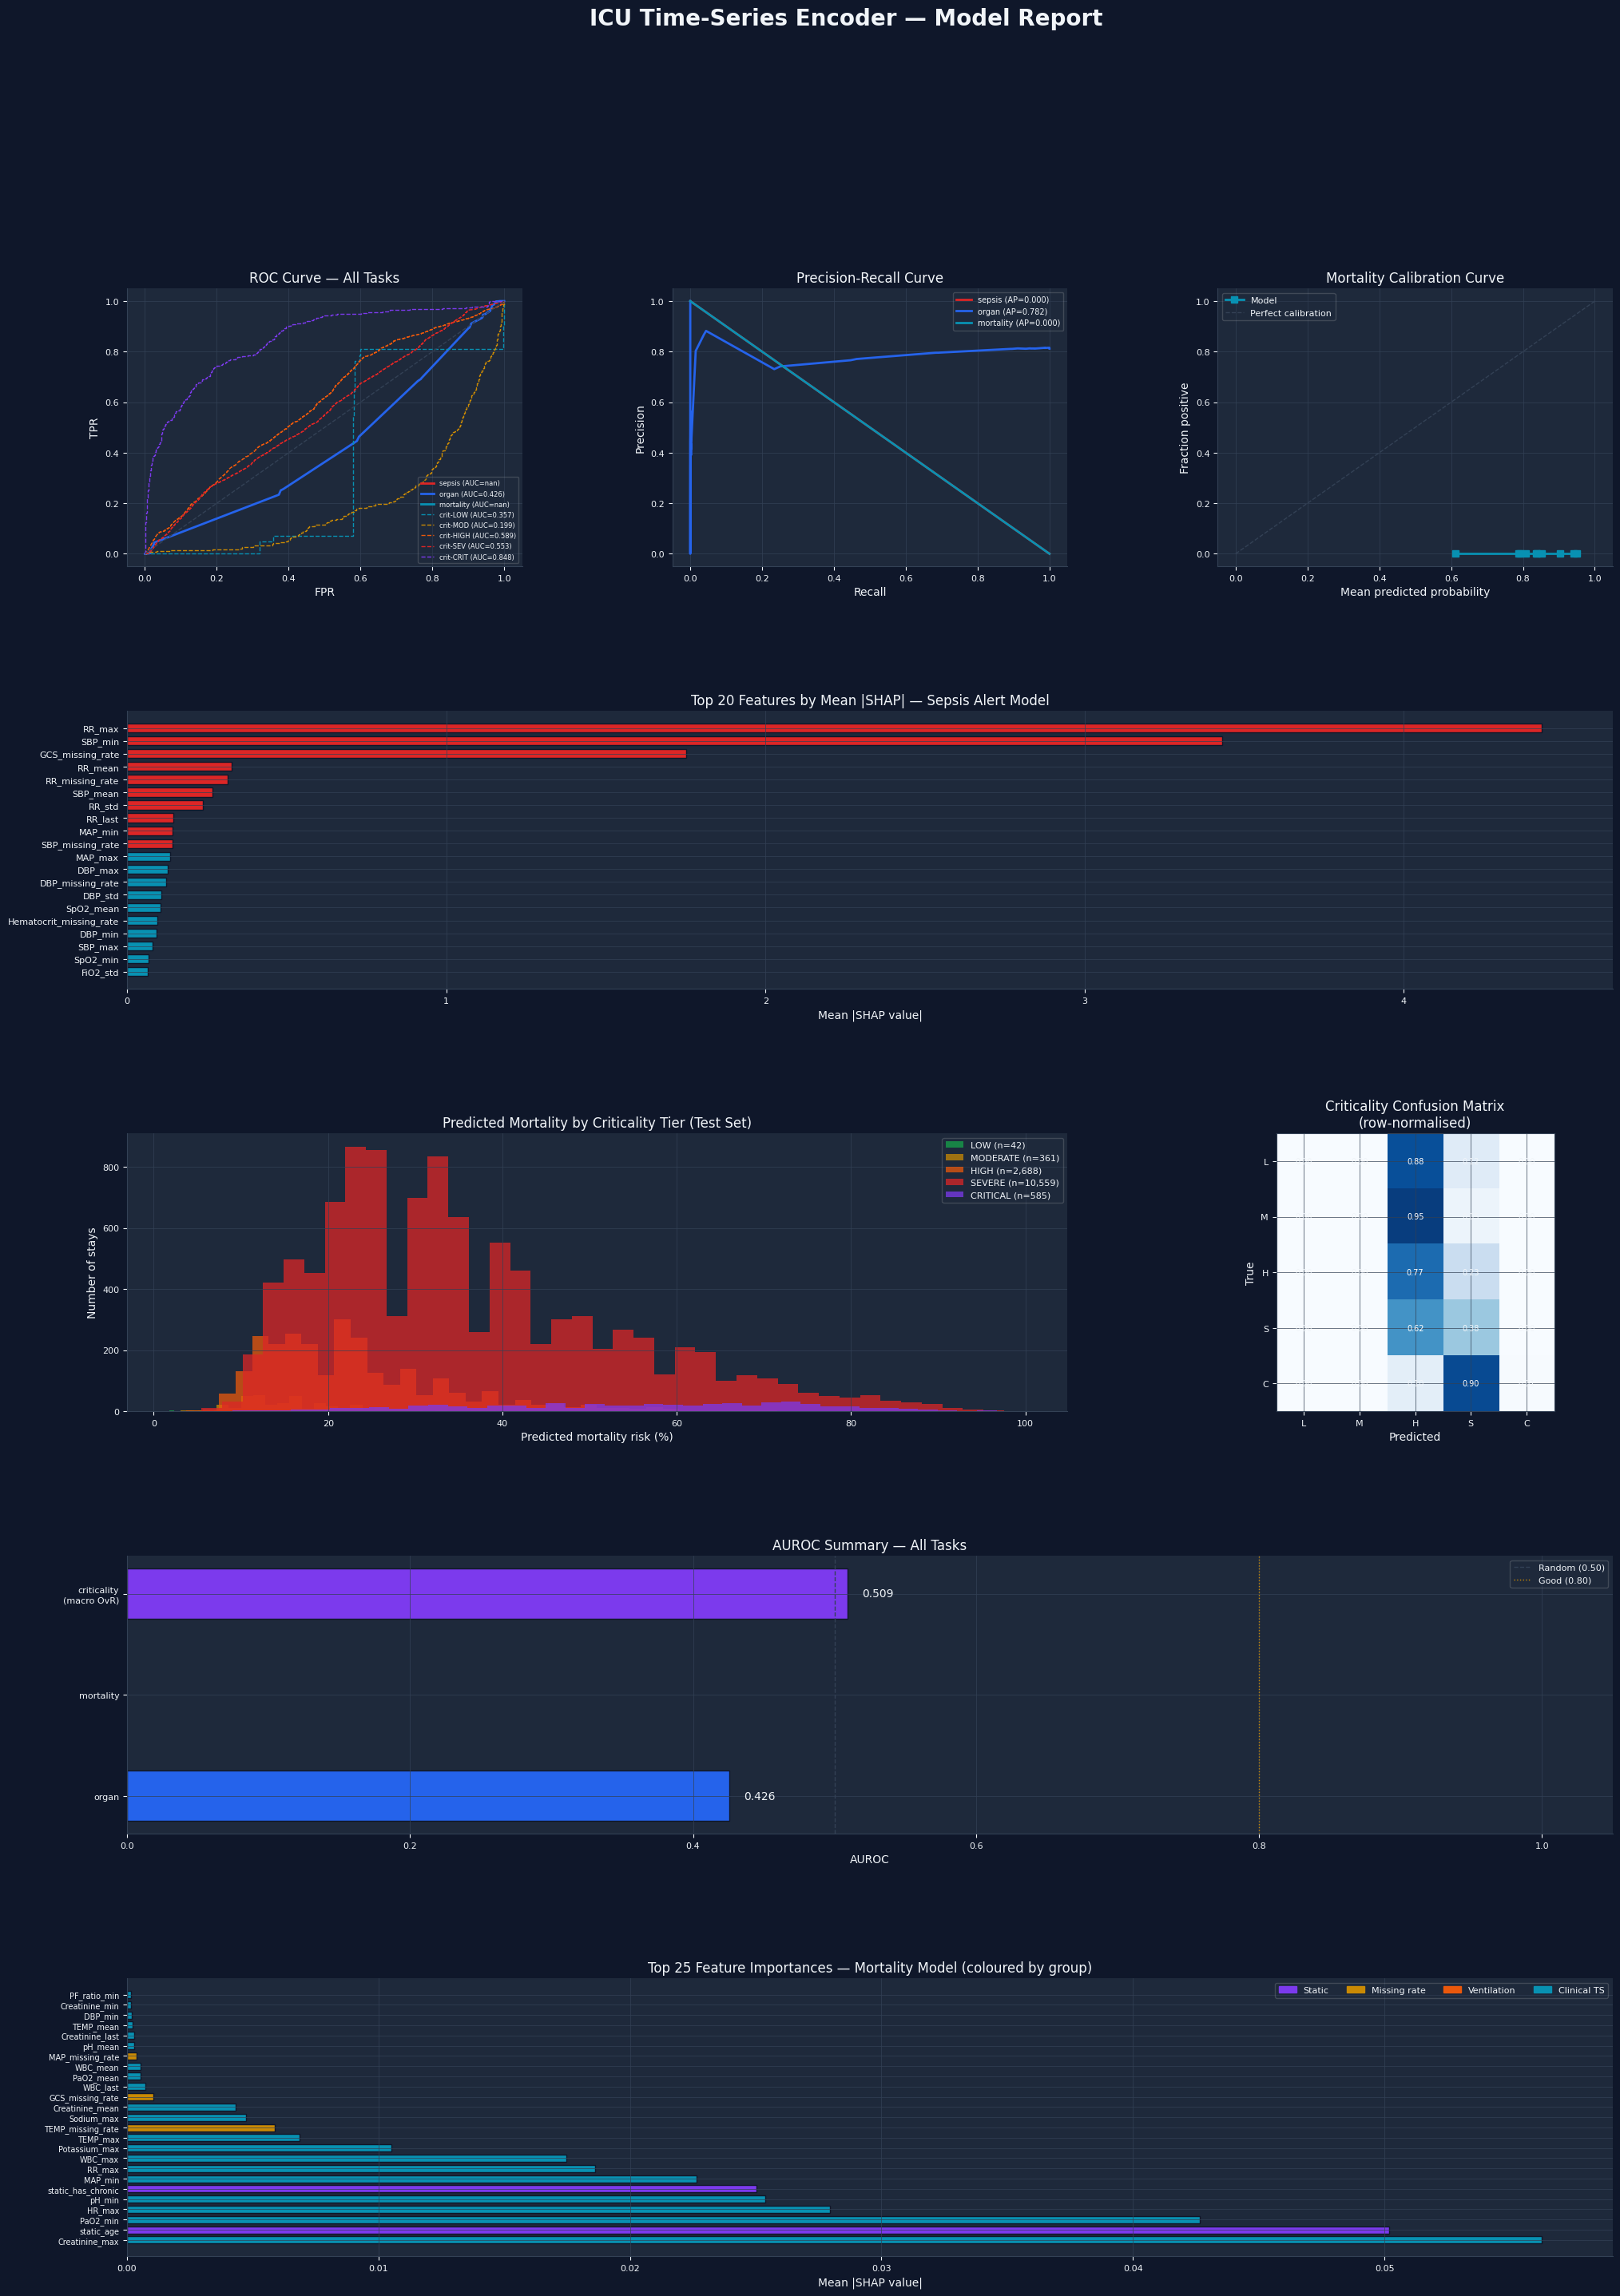

✅ Report saved → /content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/icu_encoder_report.png


In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
from sklearn.metrics import average_precision_score, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

fig = plt.figure(figsize=(24, 32), facecolor=DARK_BG)
fig.suptitle('ICU Time-Series Encoder — Model Report',
             fontsize=20, fontweight='bold', color=TEXT, y=0.99)
gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.52, wspace=0.38)

def sp(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ────────────────────────────────────────────────────────────────────
# Panel 1 — ROC curves (all tasks)
# ────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

roc_tasks = [
    ('sepsis',    PAL['red'],  'binary'),
    ('organ',     PAL['blue'], 'binary'),
    ('mortality', PAL['teal'], 'binary'),
]
for tname, color, _ in roc_tasks:
    if tname == 'mortality':
        y_prob = trained_models['mortality'].predict(X_test_df.values).clip(0, 1)
        thresh = np.percentile(y_prob, 70)
        y_true = (y_test['mortality'] >= thresh).astype(int)
    else:
        y_prob = trained_models[tname].predict_proba(X_test_df.values)[:, 1]
        y_true = y_test[tname]
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{tname} (AUC={auc:.3f})')

# Criticality per-class OvR
crit_probs = trained_models['criticality'].predict_proba(X_test_df.values)
y_crit_bin = label_binarize(y_test['criticality'], classes=list(range(5)))
tier_labels  = ['LOW', 'MOD', 'HIGH', 'SEV', 'CRIT']
tier_colors  = [PAL['teal'], PAL['yellow'], PAL['orange'], PAL['red'], PAL['purple']]
for i, (tier, col) in enumerate(zip(tier_labels, tier_colors)):
    if y_crit_bin[:, i].sum() < 2:
        continue
    fpr_i, tpr_i, _ = roc_curve(y_crit_bin[:, i], crit_probs[:, i])
    auc_i = roc_auc_score(y_crit_bin[:, i], crit_probs[:, i])
    ax1.plot(fpr_i, tpr_i, lw=1, linestyle='--', color=col,
             label=f'crit-{tier} (AUC={auc_i:.3f})')

ax1.plot([0, 1], [0, 1], '--', color=GRID, lw=1)
ax1.set_title('ROC Curve — All Tasks')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(framealpha=0.2, facecolor=CARD_BG, fontsize=6); sp(ax1)

# ────────────────────────────────────────────────────────────────────
# Panel 2 — Precision-Recall curves
# ────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for tname, color in [('sepsis', PAL['red']), ('organ', PAL['blue'])]:
    y_prob = trained_models[tname].predict_proba(X_test_df.values)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test[tname], y_prob)
    ap = average_precision_score(y_test[tname], y_prob)
    ax2.plot(rec, prec, color=color, lw=2, label=f'{tname} (AP={ap:.3f})')

y_mort_prob  = trained_models['mortality'].predict(X_test_df.values).clip(0, 1)
thresh       = np.percentile(y_mort_prob, 70)
y_mort_bin_pr = (y_test['mortality'] >= thresh).astype(int)
prec, rec, _ = precision_recall_curve(y_mort_bin_pr, y_mort_prob)
ap = average_precision_score(y_mort_bin_pr, y_mort_prob)
ax2.plot(rec, prec, color=PAL['teal'], lw=2, label=f'mortality (AP={ap:.3f})')

ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.legend(framealpha=0.2, facecolor=CARD_BG, fontsize=7); sp(ax2)

# ────────────────────────────────────────────────────────────────────
# Panel 3 — Mortality calibration
# ────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
y_mort_prob_cal = trained_models['mortality'].predict(X_test_df.values).clip(0, 1)
thresh_cal = np.percentile(y_mort_prob_cal, 70)
y_bin_cal  = (y_test['mortality'] >= thresh_cal).astype(int)
frac_pos, mean_pred = calibration_curve(y_bin_cal, y_mort_prob_cal,
                                        n_bins=10, strategy='quantile')
ax3.plot(mean_pred, frac_pos, 's-', color=PAL['teal'], lw=2, label='Model')
ax3.plot([0, 1], [0, 1], '--', color=GRID, lw=1, label='Perfect calibration')
ax3.set_title('Mortality Calibration Curve')
ax3.set_xlabel('Mean predicted probability')
ax3.set_ylabel('Fraction positive')
ax3.legend(framealpha=0.2, facecolor=CARD_BG); sp(ax3)

# ────────────────────────────────────────────────────────────────────
# Panel 4 — SHAP summary: top 20 features for Sepsis model
# ────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
shap_vals    = shap_outputs['sepsis'].values
mean_abs     = np.abs(shap_vals).mean(axis=0)
top20_idx    = np.argsort(mean_abs)[::-1][:20]
shap_feat_names = [c.replace('shap_sepsis_', '') for c in shap_df.columns if 'shap_sepsis_' in c]
top20_names  = [shap_feat_names[i] for i in top20_idx]
top20_vals   = mean_abs[top20_idx]
colors_shap  = [PAL['red'] if v > np.median(top20_vals) else PAL['teal'] for v in top20_vals]
ax4.barh(range(20), top20_vals[::-1], color=colors_shap[::-1],
         edgecolor=DARK_BG, height=0.7)
ax4.set_yticks(range(20))
ax4.set_yticklabels(top20_names[::-1], fontsize=8)
ax4.set_title('Top 20 Features by Mean |SHAP| — Sepsis Alert Model')
ax4.set_xlabel('Mean |SHAP value|'); sp(ax4)

# ────────────────────────────────────────────────────────────────────
# Panel 5 — Mortality distribution by criticality tier
# ────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
TIER_COLORS = {
    'LOW': '#16A34A', 'MODERATE': '#CA8A04', 'HIGH': '#EA580C',
    'SEVERE': '#DC2626', 'CRITICAL': '#7C3AED',
}
test_df_plot = master.loc[test_mask].copy().reset_index(drop=True)
test_df_plot['pred_mortality'] = y_mort_pred
for tier in ['LOW', 'MODERATE', 'HIGH', 'SEVERE', 'CRITICAL']:
    vals = test_df_plot.loc[test_df_plot['criticality_tier'] == tier, 'pred_mortality'] * 100
    if len(vals) < 3:
        continue
    ax5.hist(vals, bins=40, alpha=0.75, color=TIER_COLORS[tier],
             label=f'{tier} (n={len(vals):,})', edgecolor='none')
ax5.set_title('Predicted Mortality by Criticality Tier (Test Set)')
ax5.set_xlabel('Predicted mortality risk (%)'); ax5.set_ylabel('Number of stays')
ax5.legend(framealpha=0.2, facecolor=CARD_BG); sp(ax5)

# ────────────────────────────────────────────────────────────────────
# Panel 6 — Criticality confusion matrix
# ────────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
y_crit_pred = trained_models['criticality'].predict(X_test_df.values).astype(int)
y_crit_true = y_test['criticality'].values.astype(int)
cm = confusion_matrix(y_crit_true, y_crit_pred, normalize='true')
if cm.shape[0] < 5:
    pad = np.zeros((5, 5))
    pad[:cm.shape[0], :cm.shape[1]] = cm
    cm = pad
ax6.imshow(cm, cmap='Blues', vmin=0, vmax=1)
ax6.set_xticks(range(5)); ax6.set_yticks(range(5))
ax6.set_xticklabels(['L', 'M', 'H', 'S', 'C'], fontsize=8)
ax6.set_yticklabels(['L', 'M', 'H', 'S', 'C'], fontsize=8)
for i in range(5):
    for j in range(5):
        ax6.text(j, i, f'{cm[i, j]:.2f}', ha='center', va='center',
                 fontsize=7, color='white' if cm[i, j] > 0.5 else TEXT)
ax6.set_title('Criticality Confusion Matrix\n(row-normalised)')
ax6.set_xlabel('Predicted'); ax6.set_ylabel('True')

# ────────────────────────────────────────────────────────────────────
# Panel 7 — AUROC summary bar chart
# ────────────────────────────────────────────────────────────────────
ax_auc = fig.add_subplot(gs[3, :])
auc_labels, auc_values, auc_colors = [], [], []

for tname, color in [('sepsis', PAL['red']), ('organ', PAL['blue'])]:
    prob = trained_models[tname].predict_proba(X_test_df.values)[:, 1]
    auc  = roc_auc_score(y_test[tname], prob)
    auc_labels.append(tname); auc_values.append(auc); auc_colors.append(color)

prob   = trained_models['mortality'].predict(X_test_df.values).clip(0, 1)
thresh = np.percentile(prob, 70)
y_bin  = (y_test['mortality'] >= thresh).astype(int)
auc    = roc_auc_score(y_bin, prob)
auc_labels.append('mortality'); auc_values.append(auc); auc_colors.append(PAL['teal'])

crit_p = trained_models['criticality'].predict_proba(X_test_df.values)
auc_mc = roc_auc_score(y_crit_bin, crit_p, multi_class='ovr', average='macro')
auc_labels.append('criticality\n(macro OvR)'); auc_values.append(auc_mc)
auc_colors.append(PAL['purple'])

bars = ax_auc.barh(auc_labels, auc_values, color=auc_colors,
                   edgecolor=DARK_BG, height=0.5)
ax_auc.set_xlim(0, 1.05)
ax_auc.axvline(0.5, color=GRID,        lw=1, linestyle='--', label='Random (0.50)')
ax_auc.axvline(0.8, color=PAL['yellow'], lw=1, linestyle=':',  label='Good (0.80)')
for bar, val in zip(bars, auc_values):
    ax_auc.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=10, color=TEXT)
ax_auc.set_title('AUROC Summary — All Tasks')
ax_auc.set_xlabel('AUROC')
ax_auc.legend(framealpha=0.2, facecolor=CARD_BG); sp(ax_auc)

# ────────────────────────────────────────────────────────────────────
# Panel 8 — Feature importances: Mortality model (coloured by group)
# ────────────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[4, :])
mort_shap_cols  = [c for c in shap_df.columns if 'shap_mortality_' in c]
mort_feat_names = [c.replace('shap_mortality_', '') for c in mort_shap_cols]
mort_shap_vals  = shap_outputs['mortality'].values
mean_abs_mort   = np.abs(mort_shap_vals).mean(axis=0)

feat_df = pd.DataFrame({'feature': mort_feat_names, 'importance': mean_abs_mort})
feat_df['group'] = feat_df['feature'].apply(
    lambda x: 'Static'        if x.startswith('static_') else
              'Missing rate'  if x.endswith('_missing_rate') else
              'Ventilation'   if 'vent' in x else
              'Clinical TS'
)
feat_df = feat_df.sort_values('importance', ascending=False).head(25)

group_colors = {
    'Static':       PAL['purple'],
    'Missing rate': PAL['yellow'],
    'Ventilation':  PAL['orange'],
    'Clinical TS':  PAL['teal'],
}
bar_colors = [group_colors[g] for g in feat_df['group']]
ax7.barh(range(len(feat_df)), feat_df['importance'].values,
         color=bar_colors, edgecolor=DARK_BG, height=0.7)
ax7.set_yticks(range(len(feat_df)))
ax7.set_yticklabels(feat_df['feature'].values, fontsize=7)
ax7.set_title('Top 25 Feature Importances — Mortality Model (coloured by group)')
ax7.set_xlabel('Mean |SHAP value|')
legend_patches = [mpatches.Patch(color=c, label=g) for g, c in group_colors.items()]
ax7.legend(handles=legend_patches, framealpha=0.2, facecolor=CARD_BG, ncol=4)
sp(ax7)

plt.savefig(REPORT_PNG, dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Report saved → {REPORT_PNG}')

## Step 14 — Plain-Language SHAP Explanation Generator
> Given a single `stay_id`, produce a clinician-readable explanation of the model's prediction.

In [7]:
import shap

FEATURE_PLAIN_NAMES = {
    'HR_mean':            'average heart rate',
    'HR_max':             'peak heart rate',
    'RR_mean':            'average respiratory rate',
    'SpO2_min':           'lowest blood oxygen level',
    'MAP_min':            'lowest mean arterial pressure',
    'GCS_min':            'lowest consciousness score',
    'Creatinine_max':     'peak creatinine (kidney stress)',
    'Bilirubin_max':      'peak bilirubin (liver stress)',
    'Platelets_min':      'lowest platelet count (clotting)',
    'PF_ratio_min':       'lowest P/F ratio (lung function)',
    'pH_min':             'lowest blood pH (acid-base)',
    'WBC_max':            'peak white cell count (infection)',
    'vent_any':           'mechanical ventilation used',
    'vent_hours':         'hours on ventilator',
    'static_age':         'patient age',
    'static_has_chronic': 'chronic disease burden',
    'static_urine_24h':   '24h urine output',
    'static_is_elective': 'elective admission type',
    'SpO2_missing_rate':  'how often SpO2 was not recorded',
    'GCS_missing_rate':   'how often consciousness was not recorded',
}

TIER_NAMES = ['LOW', 'MODERATE', 'HIGH', 'SEVERE', 'CRITICAL']

_TASK_TYPES = {
    'mortality':   'regression',
    'sepsis':      'binary',
    'organ':       'binary',
    'criticality': 'multiclass',
}


def explain_stay(stay_id: int, task: str = 'sepsis', top_n: int = 5) -> str:
    """
    Generate a plain-language SHAP explanation for one ICU stay.

    Parameters
    ----------
    stay_id : int   — ICU stay identifier
    task    : str   — 'mortality' | 'sepsis' | 'organ' | 'criticality'
    top_n   : int   — number of top positive / negative contributors to show

    Returns
    -------
    str — formatted explanation block
    """
    row_idx = master.index[master['stay_id'] == stay_id]
    if len(row_idx) == 0:
        return f'Stay {stay_id} not found in master table.'
    idx = row_idx[0]

    # ── Preprocess the single row
    x_raw = master.loc[[idx], FEATURE_COLS]
    x_imp = imputer.transform(x_raw)
    x_sc  = scaler.transform(x_imp)
    x_df  = pd.DataFrame(x_sc, columns=FEATURE_COLS)

    model     = trained_models[task]
    task_type = _TASK_TYPES[task]

    # ── Prediction string
    if task_type == 'regression':
        val      = float(model.predict(x_df.values)[0])
        pred_str = f'{val * 100:.1f}% predicted mortality risk'
    elif task_type == 'binary':
        val      = float(model.predict_proba(x_df.values)[0, 1])
        risk_lbl = 'HIGH' if val >= 0.5 else 'LOW'
        pred_str = f'{val * 100:.1f}% probability ({risk_lbl} risk)'
    else:  # multiclass
        probs    = model.predict_proba(x_df.values)[0]
        tier     = TIER_NAMES[int(np.argmax(probs))]
        pred_str = f'Criticality tier: {tier}  (confidence {max(probs) * 100:.1f}%)'

    # ── SHAP values for this row
    explainer = shap.TreeExplainer(model.booster)
    sv = explainer.shap_values(x_df)

    if task_type == 'multiclass':
        sv_use = sv[4] if isinstance(sv, list) else sv[:, :, 4]
    elif isinstance(sv, list):
        sv_use = sv[1]
    else:
        sv_use = sv
    sv_flat = np.array(sv_use).flatten()

    top_pos = np.argsort(sv_flat)[::-1][:top_n]
    top_neg = np.argsort(sv_flat)[:top_n]

    lines = [
        f'=== Explanation for Stay {stay_id} — {task.upper()} ===',
        f'Prediction: {pred_str}',
        '',
        'Factors INCREASING this risk:',
    ]
    for i in top_pos:
        if sv_flat[i] <= 0:
            break
        fname   = FEATURE_COLS[i]
        plain   = FEATURE_PLAIN_NAMES.get(fname, fname.replace('_', ' '))
        raw_val = master.loc[idx, fname]
        lines.append(f'  + {plain}: {raw_val:.2f}  (impact: +{sv_flat[i]:.4f})')

    lines += ['', 'Factors DECREASING this risk:']
    for i in top_neg:
        if sv_flat[i] >= 0:
            break
        fname   = FEATURE_COLS[i]
        plain   = FEATURE_PLAIN_NAMES.get(fname, fname.replace('_', ' '))
        raw_val = master.loc[idx, fname]
        lines.append(f'  - {plain}: {raw_val:.2f}  (impact: {sv_flat[i]:.4f})')

    return '\n'.join(lines)


# ── Demo: explain first test-set stay
demo_stay = master.loc[test_mask, 'stay_id'].iloc[0]
print(explain_stay(demo_stay, task='sepsis'))
print()
print(explain_stay(demo_stay, task='mortality'))

KeyError: "None of [Index(['HR_mean', 'HR_std', 'HR_min', 'HR_max', 'HR_last', 'RR_mean', 'RR_std',\n       'RR_min', 'RR_max', 'RR_last',\n       ...\n       'Sodium_missing_rate', 'WBC_missing_rate', 'pH_missing_rate',\n       'vent_any', 'vent_hours', 'static_age', 'static_is_elective',\n       'static_has_chronic', 'static_urine_24h', 'static_gender_male'],\n      dtype='object', length=125)] are in the [columns]"

## Step 15 — Output Summary

In [ ]:
print('=== ICU ENCODER OUTPUTS ===')
artifact_paths = [
    FEAT_OUT,
    PRED_OUT,
    REPORT_PNG,
    BASE       / 'icu_encoder_shap_test.parquet',
    MODEL_DIR  / 'xgb_mortality.ubj',
    MODEL_DIR  / 'xgb_sepsis.ubj',
    MODEL_DIR  / 'xgb_organ.ubj',
    MODEL_DIR  / 'xgb_criticality.ubj',
    MODEL_DIR  / 'feature_meta.json',
    MODEL_DIR  / 'best_hyperparams.json',
    MODEL_DIR  / 'eval_results.json',
    MODEL_DIR  / 'imputer.pkl',
    MODEL_DIR  / 'scaler.pkl',
]
for path in artifact_paths:
    p      = Path(path)
    exists = p.exists()
    size   = p.stat().st_size / 1e6 if exists else 0.0
    status = 'OK    ' if exists else 'MISSING'
    print(f'  {status} | {size:6.1f} MB | {p.name}')

print(f'\nFeature matrix columns : {len(FEATURE_COLS)}')
print(f'Total stays encoded    : {len(master):,}')
print(f'Train / Val / Test     : '
      f'{train_mask.sum():,} / {val_mask.sum():,} / {test_mask.sum():,}')
print(f'\nModel performance:')
with open(MODEL_DIR / 'eval_results.json') as f:
    print(json.dumps(json.load(f), indent=2))